# Question 9: Food Price Spikes and Economic Anxiety in Germany

## Research Question

To what extent are increases in food prices associated with public discourse about economic concerns in Germany?

## Data Sources

This analysis combines three types of data:

- **Eurostat Consumer Price Index (CPI)** data for selected food products (butter, dairy products, and margarine) in Germany.
- **Google Trends** data capturing public search interest related to food prices.
- **YouTube comments** discussing food inflation in Germany.

The goal is to explore whether rising food prices are associated with increased public attention and expressions of economic anxiety.

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
# File paths

BUTTER_FILE = "eurostat_butter_cpi.json"
DAIRY_FILE = "eurostat_cpi_dairy.json"
MARGARINE_FILE = "margarine_cpi.json"

TRENDS_FILE = "trends_bundle.json"

YOUTUBE_COMMENTS_FILE = "youtube_food_inflation_comments_germany.json"
YOUTUBE_VIDEOS_FILE = "youtube_food_inflation_germany_videos.json"

In [3]:
def load_eurostat_json(file):

    with open(file, "r") as f:
        data = json.load(f)

    values = data["value"]
    time_index = data["dimension"]["time"]["category"]["index"]

    rows = []

    for date, idx in time_index.items():
        if str(idx) in values:
            rows.append({
                "date": pd.to_datetime(date),
                "value": values[str(idx)]
            })

    df = pd.DataFrame(rows)
    df = df.sort_values("date")

    return df

In [4]:
butter_df = load_eurostat_json(BUTTER_FILE)
dairy_df = load_eurostat_json(DAIRY_FILE)
margarine_df = load_eurostat_json(MARGARINE_FILE)

In [5]:
price_df = butter_df.copy()

price_df.rename(columns={"value":"butter_price"}, inplace=True)

price_df["dairy_price"] = dairy_df["value"]
price_df["margarine_price"] = margarine_df["value"]

In [6]:
price_df["butter_change"] = price_df["butter_price"].pct_change()
price_df["dairy_change"] = price_df["dairy_price"].pct_change()
price_df["margarine_change"] = price_df["margarine_price"].pct_change()

In [7]:
with open(TRENDS_FILE, "r") as f:
    trends = json.load(f)

butter_trend = trends["files"]["iot_Butter.json"]["data"]

trends_df = pd.DataFrame(butter_trend)

trends_df["date"] = pd.to_datetime(trends_df["date"])
trends_df.rename(columns={"value":"butter_search_interest"}, inplace=True)

In [8]:
price_df["year_month"] = price_df["date"].dt.to_period("M")
trends_df["year_month"] = trends_df["date"].dt.to_period("M")

In [9]:
merged_df = pd.merge(
    price_df,
    trends_df[["year_month","butter_search_interest"]],
    on="year_month",
    how="inner"
)

In [10]:
print(merged_df.shape)
merged_df.head()

(61, 9)


,date,butter_price,dairy_price,margarine_price,butter_change,dairy_change,margarine_change,year_month,butter_search_interest
0,2019-12-01,144.3,78.5,108.2,-0.012320,0.003836,-0.027853,2019-12,36.0
1,2020-01-01,144.9,79.0,110.9,0.004158,0.006369,0.024954,2020-01,32.0
2,2020-02-01,143.3,79.4,110.8,-0.011042,0.005063,-0.000902,2020-02,30.5
3,2020-03-01,142.7,79.9,110.6,-0.004187,0.006297,-0.001805,2020-03,31.8
4,2020-04-01,142.5,81.2,111.2,-0.001402,0.016270,0.005425,2020-04,40.0


In [11]:
# correlation between butter price and search interest
corr_now = merged_df["butter_price"].corr(merged_df["butter_search_interest"])

print("Correlation between butter price and search interest:", round(corr_now,3))

Correlation between butter price and search interest: 0.681


In [12]:
# lag analysis: earlier price -> later search interest

lag_results = {}

for lag in [1,2,3]:
    merged_df[f"price_lag_{lag}"] = merged_df["butter_price"].shift(lag)
    corr = merged_df[f"price_lag_{lag}"].corr(merged_df["butter_search_interest"])
    lag_results[lag] = corr

lag_df = pd.DataFrame({
    "lag_months": list(lag_results.keys()),
    "correlation": list(lag_results.values())
})

lag_df

,lag_months,correlation
0,1,0.657617
1,2,0.628197
2,3,0.587762


In [28]:
with open(YOUTUBE_COMMENTS_FILE,"r") as f:
    comments = json.load(f)

comments_df = pd.DataFrame(comments, columns=["comment"])

In [29]:
fear_words = [
"teuer",
"inflation",
"krise",
"arm",
"preise",
"unbezahlbar",
"existenz",
"rezession",
"sorgen",
"geld",
"wirtschaft"
]

fear_freq = {
word: word_freq[word]
for word in fear_words
}

fear_freq

{'teuer': 19,
 'inflation': 23,
 'krise': 0,
 'arm': 2,
 'preise': 50,
 'unbezahlbar': 1,
 'existenz': 0,
 'rezession': 0,
 'sorgen': 0,
 'geld': 60,
 'wirtschaft': 5}

In [34]:
def fear_score(text):

    text = str(text).lower()

    score = 0

    for word in fear_words:
        if word in text:
            score += 1

    return score

In [35]:
comments_df["fear_score"] = comments_df["comment"].apply(fear_score)
comments_df["fear_present"] = comments_df["fear_score"] > 0

fear_share = comments_df["fear_present"].mean()

print("Share of comments containing economic concern:", round(fear_share,3))

Share of comments containing economic concern: 0.421


In [36]:
discourse_summary = {
    "mean_fear_score": comments_df["fear_score"].mean(),
    "total_fear": comments_df["fear_score"].sum(),
    "n_comments": comments_df["comment"].count(),
    "share_fear_comments": comments_df["fear_present"].mean()
}

discourse_summary

{'mean_fear_score': 0.589648798521257,
 'total_fear': 319,
 'n_comments': 541,
 'share_fear_comments': 0.4214417744916821}

In [37]:
import re
from collections import Counter
import matplotlib.pyplot as plt

stopwords = {
    "die","der","das","und","ist","ich","du","er","sie","es","wir","ihr",
    "nicht","ein","eine","einer","einem","einen","den","dem","des",
    "zu","mit","für","auf","von","an","im","in","am","auch","so",
    "man","aber","noch","wie","wenn","dass","da","dann","mehr",
    "mal","nur","schon","hier","ja","nein","halt","eben",
    "sind","war","waren","wird","werden","haben","hat","hatte",
    "bei","alles","oder","als","sich","immer","wobei","jedoch",
    "aktuell","zb","zbsp","jahr",
    "was","kann","keine","muss","wieder","gibt","machen","viel",
    "zum","weniger","kein","durch","wer","uns","alle"
}

all_text = " ".join(comments_df["comment"].astype(str)).lower()
all_text = re.sub(r"[^a-zäöüß\s]", " ", all_text)

clean_words = [
    word for word in all_text.split()
    if word not in stopwords and len(word) > 2
]

word_freq = Counter(clean_words)
top_words = word_freq.most_common(15)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

In [38]:
from collections import Counter

all_words = " ".join(comments_df["comment"].astype(str)).lower().split()

filtered_words = [
    word for word in all_words
    if word not in stopwords and len(word) > 2
]

word_freq = Counter(filtered_words)

top_words = word_freq.most_common(20)

top_words

[('geld', 60),
 ('einfach', 55),
 ('preise', 50),
 ('lebensmittel', 33),
 ('viele', 30),
 ('deutschland', 30),
 ('diese', 30),
 ('euro', 29),
 ('über', 28),
 ('menschen', 28),
 ('nichts', 28),
 ('weil', 28),
 ('schokolade', 26),
 ('nach', 25),
 ('bis', 25),
 ('jetzt', 25),
 ('vor', 25),
 ('mir', 24),
 ('doch', 24),
 ('inflation', 23)]

In [48]:
fear_share = comments_df["has_fear"].mean()
print("Share of comments containing economic concern:", round(fear_share, 3))

average_fear = comments_df["fear_score"].mean()
print("Average economic fear score:", round(average_fear, 3))

Share of comments containing economic concern: 0.421
Average economic fear score: 0.59


## Interpretation

A considerable proportion of the YouTube comments contains language associated with economic concern. About 42% of all comments include at least one keyword related to prices, inflation, money, or financial hardship. In addition, the average fear score of approximately 0.59 indicates that economic concerns appear regularly across the discussion. Overall, these findings suggest that online conversations about food prices are closely linked to issues of affordability and perceived economic pressure.

## 1. Food Price Development

To understand whether food price spikes may trigger public concern,
the first step is to examine the development of consumer prices for
selected food products in Germany.

The following figure shows the evolution of the price index for
butter, dairy products, and margarine.

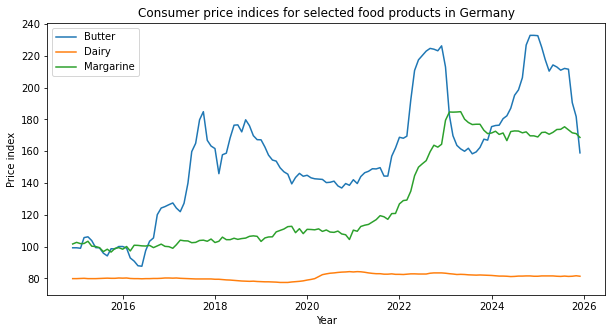

In [41]:
plt.figure(figsize=(10,5))

plt.plot(price_df["date"], price_df["butter_price"], label="Butter")
plt.plot(price_df["date"], price_df["dairy_price"], label="Dairy")
plt.plot(price_df["date"], price_df["margarine_price"], label="Margarine")

plt.legend()
plt.title("Consumer price indices for selected food products in Germany")
plt.xlabel("Year")
plt.ylabel("Price index")

plt.show()

### Interpretation

The figure illustrates the development of consumer price indices
for selected food products in Germany. All three product categories
show noticeable price increases over the observed period.

Particularly after 2021, prices rise more strongly, reflecting
the broader food inflation that occurred in Europe during this time.
These price increases can be interpreted as potential "price spikes"
that may influence public perception and economic concerns.

## 2. Price Development and Public Attention

Price increases may not only affect household budgets but also
attract public attention. One way to measure this attention is
through online search behavior.

Google Trends data provides an indicator of how frequently users
search for specific terms related to food prices. By comparing
search interest with price developments, it is possible to explore
whether rising prices are accompanied by increased public interest.

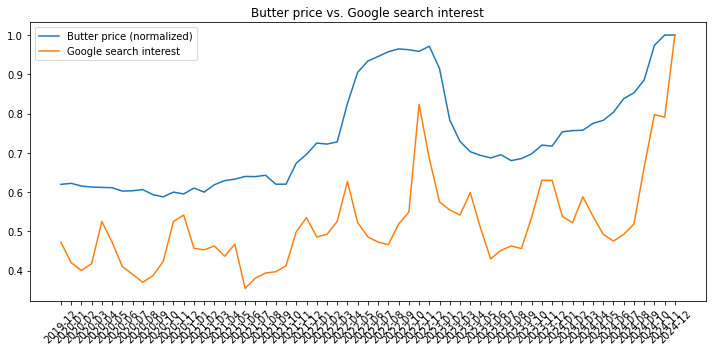

In [42]:
plt.figure(figsize=(10,5))

butter_norm = merged_df["butter_price"] / merged_df["butter_price"].max()
search_norm = merged_df["butter_search_interest"] / merged_df["butter_search_interest"].max()

plt.plot(merged_df["year_month"].astype(str), butter_norm, label="Butter price (normalized)")
plt.plot(merged_df["year_month"].astype(str), search_norm, label="Google search interest")

plt.xticks(rotation=45)
plt.legend()
plt.title("Butter price vs. Google search interest")

plt.tight_layout()
plt.show()

### Interpretation

The figure compares the normalized development of butter prices
with Google search interest. Both series are scaled to allow
a visual comparison.

Periods of rising prices appear to coincide with increased search
activity, suggesting that consumers respond to higher food prices
by seeking more information. This pattern indicates that price
developments may influence public awareness and attention.

## 3. Most Frequent Terms in the Online Discource on Food Prices

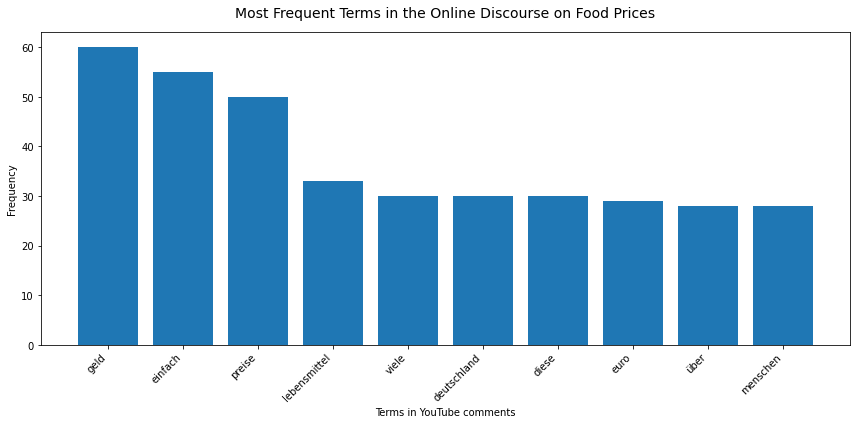

In [43]:
# Top words
top_words = word_freq.most_common(10)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.title(
    "Most Frequent Terms in the Online Discourse on Food Prices",
    fontsize=14,
    pad=15
)

plt.xlabel("Terms in YouTube comments")
plt.ylabel("Frequency")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Interpretation

The most frequently used terms in the YouTube comments highlight the central themes of the online discourse surrounding food prices. Words such as “Geld” (money), “Preise” (prices), and “Euro” appear frequently, indicating that many users discuss the financial burden associated with rising food costs. In addition, terms like “Lebensmittel” (food) and specific products such as “Schokolade” suggest that commenters often relate the broader issue of inflation to everyday consumption. Overall, the results indicate that discussions about food prices are closely linked to concerns about purchasing power and personal financial pressure.

### 4. Lagged Relationship Between Prices and Search Interest

To examine whether earlier price increases are reflected in later public attention, lagged correlations are calculated between butter prices and Google search interest. This helps evaluate whether price spikes are associated with increased search activity in the following months.

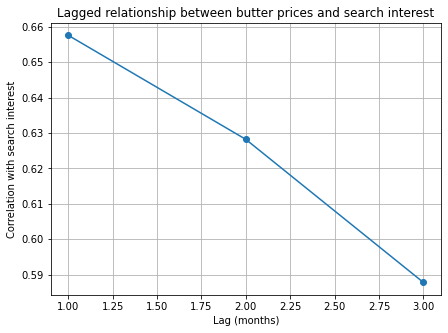

In [45]:
plt.figure(figsize=(7,5))

plt.plot(lag_df["lag_months"], lag_df["correlation"], marker="o")

plt.xlabel("Lag (months)")
plt.ylabel("Correlation with search interest")
plt.title("Lagged relationship between butter prices and search interest")

plt.grid(True)

plt.show()

### Interpretation

The lagged correlations help assess whether increases in butter prices are followed by higher public attention in subsequent months. 

If the correlations remain positive for one or more lag periods, this suggests that price increases may not only trigger immediate reactions but may also influence public attention over time. In other words, rising food prices may contribute to sustained public concern and discussion rather than only short-term interest.

However, these correlations should be interpreted cautiously. They indicate association rather than causation and do not prove that price increases directly cause changes in search behavior.

## 5. Economic Anxiety in Online Discussions

Beyond search behavior, public discourse about food prices can
also be observed in online discussions. YouTube comments related
to food inflation in Germany provide qualitative insights into
how people perceive rising prices.

To quantify economic concern, a simple "fear score" is calculated
based on the presence of keywords related to economic anxiety
such as *expensive*, *inflation*, *crisis*, or *affordability*.

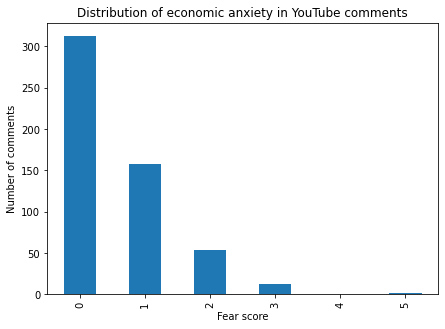

In [46]:
plt.figure(figsize=(7,5))

comments_df["fear_score"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Fear score")
plt.ylabel("Number of comments")
plt.title("Distribution of economic anxiety in YouTube comments")

plt.show()

### Interpretation

The distribution of fear scores indicates that a considerable
share of comments contains language associated with economic
concerns. Many users refer to rising prices, financial pressure,
or the affordability of food.

These findings suggest that discussions about food prices are
often framed in terms of economic insecurity and household
financial stress.

## 5. Conclusion

This analysis explored whether spikes in food prices are reflected
in public attention and online discussions in Germany.

The results show that food prices increased substantially during
the observed period. At the same time, Google search interest
indicates that consumers pay greater attention to these issues
when prices rise.

Additionally, YouTube comments reveal that discussions about food
prices frequently contain expressions of economic anxiety and
concerns about affordability. While the analysis does not establish
causal relationships, it suggests that rising food prices may
contribute to increased public concern and awareness.